# 📐 Probability Distributions & Parametric Modeling

**Course**: Machine Learning Mathematics — Lecture Notes
**Topic**: Discrete Probability Mass Functions (Bernoulli, Binomial, Poisson) and Continuous Normal (Gaussian) Densities

## 1. Foundations of Probability Distributions: PMF vs. PDF

### Intuition First
A probability distribution maps possible outcomes of a random variable to their respective occurrence likelihoods. 
- For **discrete random variables**, the **Probability Mass Function (PMF)** assigns exact probabilities to distinct countable outcomes $x \in \mathcal{X}$, satisfying $\sum_{x} P(X = x) = 1$.
- For **continuous random variables**, the **Probability Density Function (PDF)** models likelihood over continuous intervals, where individual point probabilities are zero and continuous intervals represent probability mass through integration: $\int_{-\infty}^{\infty} f(x) \, dx = 1$.

### Connection to the Code
The imports below set up numerical arrays (`numpy`), visualization tools (`matplotlib`, `seaborn`), and standard distribution modules from `scipy.stats`.

**Key Takeaway**: **Discrete distributions use PMFs with summations, while continuous distributions use PDFs with integrals.**

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from scipy.stats import bernoulli
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import norm

## 2. The Bernoulli Distribution (Binary Outcomes)

### Intuition First
The Bernoulli distribution models a single random trial with two mutually exclusive outcomes: success ($x=1$ with probability $p$) and failure ($x=0$ with probability $q = 1-p$). It forms the probabilistic foundation for logistic regression classification and binary cross-entropy loss functions.

### Formal Definition / Math
For a binary random variable $X \in \{0, 1\}$ with success parameter $p \in [0, 1]$:

$$\begin{equation}
P(X = x) = p^x (1-p)^{1-x} = \begin{cases} p & \text{if } x = 1 \\ 1-p & \text{if } x = 0 \end{cases}
\end{equation}$$

- **Expectation (Mean)**: $\mathbb{E}[X] = p$
- **Variance**: $\text{Var}(X) = p(1-p)$

### Connection to the Code
- `bernoulli.rvs(size=10, p=0.6)`: Generates 10 independent random variates sampled from $\text{Bernoulli}(p=0.6)$.

**Key Takeaway**: **The Bernoulli distribution is the atomic model for binary trials and indicator random variables.**

In [3]:
d = bernoulli.rvs(size=10, p=0.6)
d

array([0, 1, 0, 1, 1, 1, 1, 1, 0, 0])

## 3. The Binomial Distribution (Repeated Independent Trials)

### Intuition First
The Binomial distribution models the total number of successes $k$ observed across $n$ independent and identically distributed (i.i.d.) Bernoulli trials, each with success probability $p$. It is widely applied in hypothesis testing, evaluation of binary classifiers, and ensemble voting models.

### Formal Definition / Math
For $X \sim \text{Binomial}(n, p)$, the probability mass function for $k \in \{0, 1, \dots, n\}$ is:

$$\begin{equation}
P(X = k) = \binom{n}{k} p^k (1-p)^{n-k} = \frac{n!}{k!(n-k)!} p^k (1-p)^{n-k}
\end{equation}$$

- **Expectation**: $\mathbb{E}[X] = n p$
- **Variance**: $\text{Var}(X) = n p (1-p)$

### Connection to the Code
- `binom.pmf(3, 4, 0.98)`: Computes the exact probability of observing $k=3$ successes out of $n=4$ trials with $p=0.98$:

$$\begin{equation}
P(X = 3) = \binom{4}{3} (0.98)^3 (0.02)^1 = 4 \times 0.941192 \times 0.02 \approx 0.075295
\end{equation}$$

**Key Takeaway**: **The Binomial distribution aggregates independent Bernoulli trials, modeling cumulative success rates in bounded sample sizes.**

In [4]:
# f(x) = (p ** x) * (q ** (1-x))

In [5]:
binom.pmf(3, 4, 0.98)  # probability mass function

np.float64(0.07529536000000013)

## 4. The Poisson Distribution (Rare Events & Count Processes)

### Intuition First
The Poisson distribution models the number of discrete events occurring within a fixed time interval or spatial region, given a known constant average arrival rate $\lambda$. It represents the continuous-trial limit of the Binomial distribution ($n \to \infty, p \to 0$ with $np = \lambda$).

### Formal Definition / Math
For discrete count $k \in \{0, 1, 2, \dots\}$ with rate parameter $\lambda > 0$:

$$\begin{equation}
P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}
\end{equation}$$

- **Expectation**: $\mathbb{E}[X] = \lambda$
- **Variance**: $\text{Var}(X) = \lambda$

### Connection to the Code
- `poisson.pmf(3, 2)`: Evaluates the probability of observing exactly $k=3$ events when the mean arrival rate is $\lambda = 2$:

$$\begin{equation}
P(X = 3) = \frac{2^3 e^{-2}}{3!} = \frac{8 e^{-2}}{6} \approx 0.180447
\end{equation}$$

**Key Takeaway**: **The Poisson distribution models event counts where expectation equals variance ($\mathbb{E}[X] = \text{Var}(X) = \lambda$).**

In [6]:
# f(x) = c(x,n) * ((p ** x) * (q ** (n-x))

In [7]:
poisson.pmf(3, 2)  # ((e ** (-2) * (2 ** 3)) / 6)

np.float64(0.18044704431548356)

## 5. The Normal (Gaussian) Distribution & Continuous Probability Density

### Intuition First
The Normal (Gaussian) distribution is the most widely utilized continuous distribution in machine learning. By the **Central Limit Theorem**, the sum (or mean) of many independent random variables tends toward a Gaussian distribution, regardless of their underlying distributions.

### Formal Definition / Math
For continuous variable $x \in \mathbb{R}$ parameterized by mean $\mu$ and standard deviation $\sigma > 0$:

$$\begin{equation}
f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left( -\frac{(x - \mu)^2}{2\sigma^2} \right)
\end{equation}$$

- **Expectation**: $\mathbb{E}[X] = \mu$
- **Variance**: $\text{Var}(X) = \sigma^2$

*(Note: For exponential derivative calculations, see [6.Derivative.ipynb](6.Derivative.ipynb). For area integration under continuous curves, see [7.Integrate.ipynb](7.Integrate.ipynb).)*

### Connection to the Code
- `norm.rvs(size=100000)`: Samples 100,000 continuous values from standard Gaussian $\mathcal{N}(\mu=0, \sigma^2=1)$.
- `sns.histplot(d)`: Displays empirical density distribution.
- `plt.plot(bins, a, color='red')`: Overlays analytical Gaussian PDF $f(x)$ over empirical histogram bins.

**Key Takeaway**: **The Gaussian distribution provides continuous density modeling with symmetric bell-shaped curves defined entirely by mean $\mu$ and spread $\sigma$.**

<Axes: ylabel='Count'>

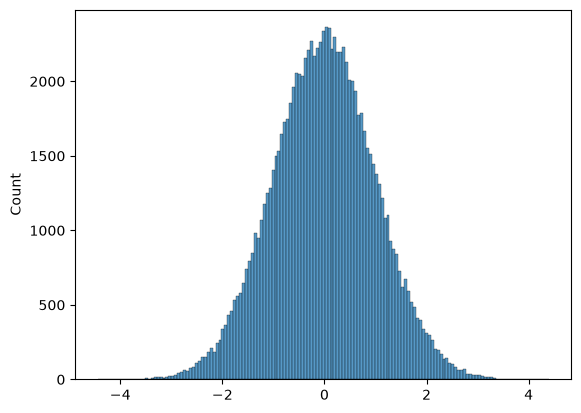

In [8]:
d = norm.rvs(size=100000)
sns.histplot(d)

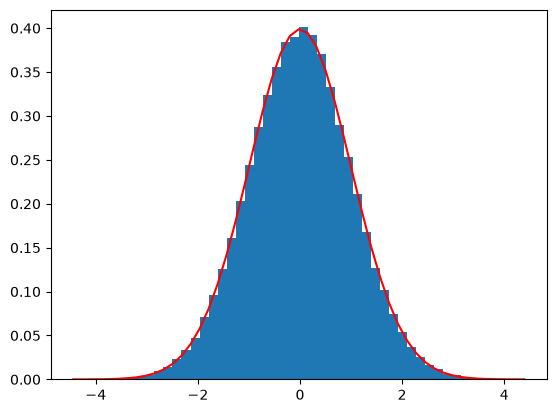

In [9]:
_, bins, _ = plt.hist(d, 50, density=True)
mu = 0
s = 1
a = 1 / (s * np.sqrt(2 * np.pi)) * np.exp(-((bins - mu) ** 2) / (2 * s**2))
plt.plot(bins, a, color="red")
plt.show()